# Results

Figures for the report. Everything here imports from the `rubiks` package,
which is covered by the test suite -- this notebook only reads results and
plots them, it does not define any of the logic.

Long jobs stay in `scripts/` (they take minutes and should survive a kernel
restart):

- `python scripts/build_2x2_table.py` -> `data/table_2x2.pkl`
- `python scripts/build_corner_pdb.py` -> `data/corner_pdb.npy`
- `python scripts/train.py --name adi` -> `runs/adi/`

In [1]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"
RUNS = ROOT / "runs"

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## Corner pattern database

Exact distance-to-solved for all 8!x3^7 = 88,179,840 corner states. This is
the admissible heuristic the hybrid search will use: no cube can be solved
in fewer moves than its corners alone require.

states: 88,179,840
max distance: 11
  depth  0:            1
  depth  1:           18
  depth  2:          243
  depth  3:        2,874
  depth  4:       28,000
  depth  5:      205,416
  depth  6:    1,168,516
  depth  7:    5,402,628
  depth  8:   20,776,176
  depth  9:   45,391,616
  depth 10:   15,139,616
  depth 11:       64,736


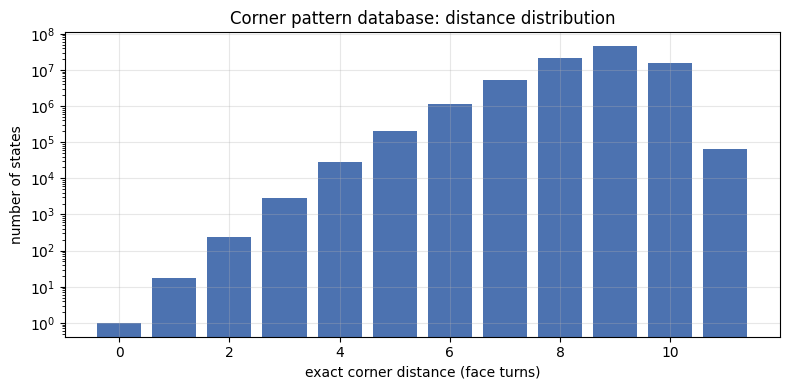

In [2]:
pdb = np.load(DATA / "corner_pdb.npy", mmap_mode="r")
counts = np.bincount(np.asarray(pdb))

print(f"states: {counts.sum():,}")
print(f"max distance: {counts.argmax() and len(counts) - 1}")
for depth, count in enumerate(counts):
    print(f"  depth {depth:2d}: {count:>12,}")

fig, ax = plt.subplots()
ax.bar(range(len(counts)), counts, color="#4C72B0")
ax.set_xlabel("exact corner distance (face turns)")
ax.set_ylabel("number of states")
ax.set_title("Corner pattern database: distance distribution")
ax.set_yscale("log")
plt.tight_layout()

## 2x2x2 ground truth

The full pocket cube, used to validate the pipeline against a case where
every optimal answer is known. Recomputed here to a shallow depth so the
cell stays fast; `scripts/build_2x2_table.py` runs it to completion
(3,674,160 states, max depth 11).

[1, 9, 54, 321, 1847, 9992, 50136, 227536, 870072]

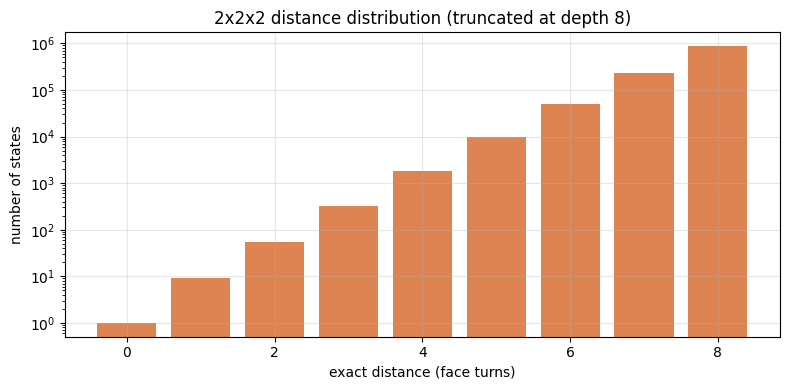

In [3]:
from rubiks.bfs2x2 import build_table

_, depth_counts = build_table(max_depth=8)

fig, ax = plt.subplots()
ax.bar(range(len(depth_counts)), depth_counts, color="#DD8452")
ax.set_xlabel("exact distance (face turns)")
ax.set_ylabel("number of states")
ax.set_title("2x2x2 distance distribution (truncated at depth 8)")
ax.set_yscale("log")
plt.tight_layout()

depth_counts

## Training curves

Note on `target_accuracy`: this is how often the network's argmax matches
the bootstrapped target it was just given, **not** how often it picks a
genuinely optimal move. It measures self-consistency. Real move quality is
measured separately against the pattern database and the 2x2x2 table.

runs found: ['adi_d12', 'smoke']


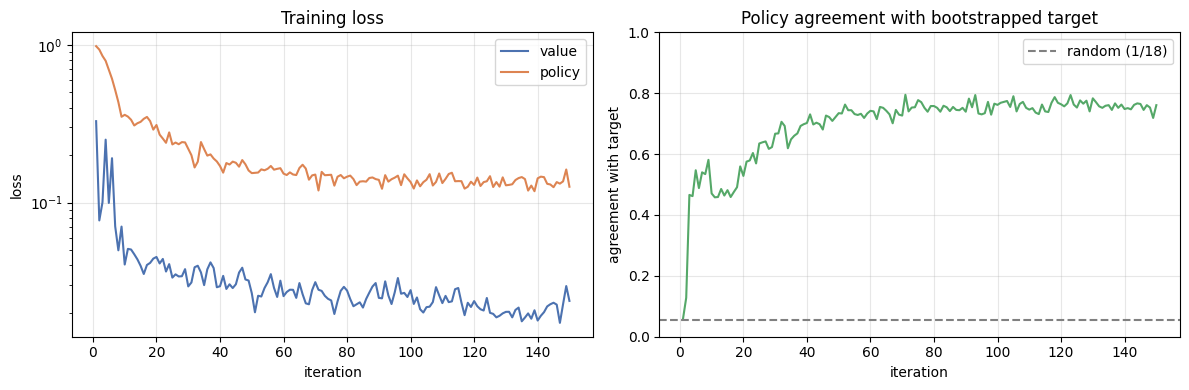

In [4]:
def load_log(name):
    path = RUNS / name / "log.csv"
    with open(path) as handle:
        rows = list(csv.DictReader(handle))
    return {key: np.array([float(r[key]) for r in rows]) for key in rows[0]}


available = sorted(p.parent.name for p in RUNS.glob("*/log.csv"))
print("runs found:", available)

log = load_log(available[-1])

fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4))
left.plot(log["iteration"], log["value_loss"], label="value", color="#4C72B0")
left.plot(log["iteration"], log["policy_loss"], label="policy", color="#DD8452")
left.set_xlabel("iteration")
left.set_ylabel("loss")
left.set_yscale("log")
left.legend()
left.set_title("Training loss")

right.plot(log["iteration"], log["target_accuracy"], color="#55A868")
right.axhline(1 / 18, linestyle="--", color="grey", label="random (1/18)")
right.set_xlabel("iteration")
right.set_ylabel("agreement with target")
right.set_ylim(0, 1)
right.legend()
right.set_title("Policy agreement with bootstrapped target")
plt.tight_layout()

## Inspecting a trained network

Scramble a cube, then look at what the network thinks -- its value estimate
and the moves it favours -- alongside the exact corner distance from the
pattern database.

In [5]:
import torch

from rubiks.cube import ALL_MOVES, apply_sequence, solved_state
from rubiks.encoding import encode
from rubiks.network import CubeNet, default_device
from rubiks.pattern_db import lookup

device = default_device()
checkpoint = torch.load(RUNS / available[-1] / "checkpoint.pt", map_location=device)
saved = checkpoint["args"]
model = CubeNet(trunk=tuple(saved["trunk"]), head=saved["head"]).to(device)
model.load_state_dict(checkpoint["model"])
model.eval()

rng = np.random.default_rng(0)
scramble = [ALL_MOVES[i] for i in rng.integers(18, size=5)]
state = apply_sequence(solved_state(), scramble)
print("scramble:", " ".join(scramble))
print("exact corner distance:", lookup(np.asarray(pdb), state))

with torch.no_grad():
    value, logits = model(torch.from_numpy(encode(state)).to(device))

print(f"value estimate: {value.item():.3f}")
probabilities = torch.softmax(logits[0], dim=0).cpu().numpy()
for index in np.argsort(-probabilities)[:5]:
    print(f"  {ALL_MOVES[index]:>3}  {probabilities[index]:.3f}")

scramble: B D2 D R' R2
exact corner distance: 3
value estimate: -1.199
   R'  0.906
    D  0.062
    R  0.015
   D2  0.005
   R2  0.004


## Cache study

Does sharing scramble prefixes make a cache worthwhile? Data from
`python scripts/cache_study.py` (writes `runs/cache_study/`); full write-up in
FINDINGS.md under *Cache study*.

Within one training iteration the network's weights are fixed, so a child
position that appears several times in a batch only needs evaluating once.
That saving is exact, so it can be measured without any training. The cell
prints both tables before drawing, so no value depends on reading a chart, and
saves the figures to `figures/` for the report.

In [ ]:
from matplotlib.ticker import PercentFormatter

plt.rcParams["font.family"] = ["Segoe UI", "DejaVu Sans"]

CHART = {
    "surface": "#fcfcfb",
    "ink": "#0b0b0b",
    "ink_secondary": "#52514e",
    "ink_muted": "#898781",
    "grid": "#e1e0d9",
    "axis": "#c3c2b7",
    # Categorical slots 1-2, validated together on this surface.
    "series": ["#2a78d6", "#eb6834"],
}
FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)


def style_axes(ax):
    ax.set_facecolor(CHART["surface"])
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(CHART["axis"])
        ax.spines[side].set_linewidth(0.8)
    ax.grid(True, axis="y", color=CHART["grid"], linewidth=0.8, linestyle="-", alpha=1)
    ax.grid(False, axis="x")
    ax.set_axisbelow(True)
    ax.tick_params(length=0, labelcolor=CHART["ink_muted"])
    ax.xaxis.label.set_color(CHART["ink_secondary"])
    ax.yaxis.label.set_color(CHART["ink_secondary"])
    ax.title.set_color(CHART["ink"])


def plot_series(ax, x, y, color, label):
    ax.plot(x, y, color=color, linewidth=2, solid_capstyle="round", solid_joinstyle="round",
            marker="o", markersize=7, markeredgecolor=CHART["surface"], markeredgewidth=1.5,
            label=label)


def load_table(path):
    with open(path) as handle:
        rows = list(csv.DictReader(handle))
    return {key: np.array([float(row[key]) for row in rows]) for key in rows[0]}


cache = load_table(RUNS / "cache_study" / "summary.csv")
by_depth = load_table(RUNS / "cache_study" / "by_depth.csv")
depth_keys = [key for key in by_depth if key.startswith("depth_")]
depths = np.array([int(key.split("_")[1]) for key in depth_keys])


def distinct_by_depth(rate):
    row = int(np.argmin(np.abs(by_depth["prefix_sharing"] - rate)))
    return np.array([by_depth[key][row] for key in depth_keys])


# Tables first, so no value depends on reading a chart.
print("sharing".rjust(8), "evaluations saved".rjust(18), "distinct positions".rjust(19))
for rate, saved, distinct in zip(cache["prefix_sharing"], cache["evaluations_saved"], cache["distinct_states"]):
    print(f"{rate:>8.0%} {saved:>18.1%} {distinct:>19.1%}")
print()
print("depth".rjust(5), "independent".rjust(12), "90% sharing".rjust(12))
for depth, independent, shared in zip(depths, distinct_by_depth(0.0), distinct_by_depth(0.9)):
    print(f"{depth:>5} {independent:>12.0%} {shared:>12.0%}")

# Figure 1: both quantities against the sharing rate, on one honest 0-100% axis.
fig, ax = plt.subplots(figsize=(7.5, 4.2), facecolor=CHART["surface"])
style_axes(ax)
rates = cache["prefix_sharing"]
measures = [
    ("Target evaluations a cache would skip", cache["evaluations_saved"]),
    ("Distinct training positions per batch", cache["distinct_states"]),
]
for (label, values), color in zip(measures, CHART["series"]):
    plot_series(ax, rates, values, color, label)
    for x, y, offset, align in ((rates[0], values[0], -10, "right"), (rates[-1], values[-1], 10, "left")):
        ax.annotate(f"{y:.0%}", xy=(x, y), xytext=(offset, 0), textcoords="offset points",
                    ha=align, va="center", fontsize=9, color=CHART["ink_secondary"])
ax.set_xlim(-0.12, 1.02)
ax.set_ylim(0, 1)
ax.set_xticks(rates)
ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_xlabel("Prefix sharing (chance per step that a scramble continues from a shared position)")
ax.set_ylabel("Share of batch")
ax.set_title("Sharing scramble prefixes barely changes either quantity", loc="left", fontsize=11)
ax.legend(loc="center left", bbox_to_anchor=(0.0, 0.58), frameon=False,
          labelcolor=CHART["ink_secondary"], fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES / "cache_prefix_sharing.png", dpi=200, facecolor=CHART["surface"], bbox_inches="tight")

# Figure 2: where the repeats are, by depth.
fig, ax = plt.subplots(figsize=(7.5, 4.2), facecolor=CHART["surface"])
style_axes(ax)
settings = [("Independent scrambles (as trained)", 0.0), ("90% prefix sharing", 0.9)]
for (label, rate), color in zip(settings, CHART["series"]):
    plot_series(ax, depths, distinct_by_depth(rate), color, label)
ax.annotate("Only 18 positions exist\none move from solved", xy=(1, distinct_by_depth(0.0)[0]),
            xytext=(28, 18), textcoords="offset points", fontsize=9, color=CHART["ink_secondary"],
            arrowprops={"arrowstyle": "-", "color": CHART["ink_muted"], "linewidth": 0.8})
ax.set_xlim(0.5, 12.5)
ax.set_ylim(0, 1.05)
ax.set_xticks(depths)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_xlabel("Scramble depth")
ax.set_ylabel("Distinct positions (share of 256 scrambles)")
ax.set_title("Repeated positions come from shallow depths, not from sharing", loc="left", fontsize=11)
ax.legend(loc="lower right", frameon=False, labelcolor=CHART["ink_secondary"], fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES / "cache_distinct_by_depth.png", dpi=200, facecolor=CHART["surface"], bbox_inches="tight")